# Pac-Man Multitask World Model

**Notebook esplorativo del progetto DLAI 2026** --- Sapienza Università di Roma --- Prof. Rodolà

Questo notebook è la **vista interattiva** del progetto. Il codice è organizzato in modo modulare nella cartella `src/` (classi e funzioni) e in script `train_*.py` (training loop). Il notebook qui:

1. Rileva l'ambiente di esecuzione (Kaggle / Colab / locale)
2. Clona o accede al codice modulare
3. Importa le classi da `src/`
4. Lancia training oppure mostra visualizzazioni inline

**Per la riproducibilità completa**: tutti i seed sono fissati a 42. Lanciare con "Run All" da sessione pulita.

## Struttura del repository

```
pacman-worldmodel/
├── src/                       # Codice modulare riusabile
│   ├── utils.py               # set_seed, make_averager
│   ├── dataset.py             # Raccolta dati, Dataset PyTorch
│   ├── models.py              # PacmanWorldModel, VectorQuantizer, VQVAE
│   └── transformers.py        # 3 Transformer (Classifier + 2 Prior)
├── conf/                      # Configurazioni Hydra
├── notebook/
│   └── PacMan_WorldModel.ipynb  # ← questo file
├── train_baseline.py
├── train_vqvae.py
├── train_transformer.py
├── train_token_prior.py
├── train_frame_prior.py
└── test.py
```

## 1 — Setup ambiente multi-piattaforma

Rilevamento automatico dell'ambiente di esecuzione e configurazione path coerenti.

In [1]:
# Rilevamento ambiente: Kaggle / Colab / Locale
import os
import sys

if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    ENVIRONMENT = 'kaggle'
    BASE_DIR = '/kaggle/working'
    REPO_DIR = '/kaggle/working/pacman-world-model'

    # Path multipli per i diversi Kaggle Datasets/Models attaccati
    IN_VQ          = '/kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1'
    IN_PRIOR       = '/kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1'
    IN_CLS         = '/kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1'
    IN_FRAME_PRIOR = '/kaggle/input/models/leonardocostantini02/modeels2/pytorch/default/1'
    IN_GIFS        = '/kaggle/input/models/leonardocostantini02/modeels3/pytorch/default/1'
    IN_DATASET_50K = '/kaggle/input/dataseets/leonardocostantini02/dataset'

elif 'google.colab' in sys.modules:
    ENVIRONMENT = 'colab'
    BASE_DIR = '/content'
    REPO_DIR = '/content/pacman-world-model'

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    # Su Colab i pesi sono tutti nella stessa cartella di Drive
    DRIVE_FOLDER   = '/content/drive/MyDrive/pacman-pesi'
    IN_VQ          = DRIVE_FOLDER
    IN_PRIOR       = DRIVE_FOLDER
    IN_CLS         = DRIVE_FOLDER
    IN_FRAME_PRIOR = DRIVE_FOLDER
    IN_GIFS        = DRIVE_FOLDER
    IN_DATASET_50K = DRIVE_FOLDER

    os.makedirs(DRIVE_FOLDER, exist_ok=True)

else:
    ENVIRONMENT = 'local'
    # In locale assumiamo che il notebook sia in pacman-world-model/notebook/
    REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
    BASE_DIR = os.path.join(REPO_DIR, 'checkpoints')
    os.makedirs(BASE_DIR, exist_ok=True)

    # In locale tutto nella stessa cartella checkpoints/
    IN_VQ = IN_PRIOR = IN_CLS = IN_FRAME_PRIOR = IN_GIFS = IN_DATASET_50K = BASE_DIR

print(f"Detected environment: {ENVIRONMENT}")
print(f"REPO_DIR:        {REPO_DIR}")
print(f"BASE_DIR:        {BASE_DIR}  (output)")
print(f"IN_VQ:           {IN_VQ}")
print(f"IN_PRIOR:        {IN_PRIOR}")
print(f"IN_CLS:          {IN_CLS}")
print(f"IN_FRAME_PRIOR:  {IN_FRAME_PRIOR}")
print(f"IN_GIFS:         {IN_GIFS}")
print(f"IN_DATASET_50K:  {IN_DATASET_50K}")

Mounted at /content/drive
Detected environment: colab
REPO_DIR:        /content/pacman-world-model
BASE_DIR:        /content  (output)
IN_VQ:           /content/drive/MyDrive/pacman-pesi
IN_PRIOR:        /content/drive/MyDrive/pacman-pesi
IN_CLS:          /content/drive/MyDrive/pacman-pesi
IN_FRAME_PRIOR:  /content/drive/MyDrive/pacman-pesi
IN_GIFS:         /content/drive/MyDrive/pacman-pesi
IN_DATASET_50K:  /content/drive/MyDrive/pacman-pesi


## 2 — Acquisizione codice modulare

Su Kaggle/Colab: clona la repo da GitHub. In locale: usa il codice già presente.

> **TODO**: sostituisci `<TUO-USERNAME>` con il tuo username GitHub.

In [2]:
GITHUB_REPO_URL_PUBLIC = "https://github.com/leonardoCosta02/pacman-world-model.git"
github_token = None

# Carica il token dal secret in base all'ambiente
if ENVIRONMENT == 'kaggle':
    try:
        from kaggle_secrets import UserSecretsClient
        github_token = UserSecretsClient().get_secret("GITHUB_TOKEN")
        print("✅ GitHub token loaded from Kaggle secrets")
    except Exception as e:
        print(f"⚠️ Could not load GITHUB_TOKEN: {e}")

elif ENVIRONMENT == 'colab':
    try:
        from google.colab import userdata
        github_token = userdata.get('GITHUB_TOKEN')
        print("✅ GitHub token loaded from Colab secrets")
    except Exception as e:
        print(f"⚠️ Could not load GITHUB_TOKEN: {e}")

# Costruisci URL autenticato se abbiamo il token
if github_token:
    GITHUB_REPO_URL = GITHUB_REPO_URL_PUBLIC.replace(
        "https://github.com",
        f"https://{github_token}@github.com"
    )
else:
    GITHUB_REPO_URL = GITHUB_REPO_URL_PUBLIC

# Pulisci eventuale cartella vuota da clone fallito precedente
import shutil
if os.path.exists(REPO_DIR) and not os.listdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print(f"Removed empty repo dir: {REPO_DIR}")

# Clone o pull
if ENVIRONMENT in ('kaggle', 'colab'):
    import subprocess
    if not os.path.exists(REPO_DIR):
        print(f"Cloning private repo...")
        result = subprocess.run(
            ['git', 'clone', GITHUB_REPO_URL, REPO_DIR],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print("✅ Clone successful")
        else:
            print(f"⚠️ Clone failed with exit code {result.returncode}")
            err = result.stderr
            if github_token:
                err = err.replace(github_token, "***TOKEN***")
            print(err)
    else:
        print(f"Repo already present at {REPO_DIR}. Pulling latest changes...")
        subprocess.run(['git', '-C', REPO_DIR, 'pull'], capture_output=True, text=True)
else:
    print(f"Local environment: using existing code at {REPO_DIR}")

# Aggiungi la repo al PYTHONPATH
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"\nPYTHONPATH includes: {REPO_DIR}")
print(f"Repo contents:")
if os.path.exists(REPO_DIR):
    for item in sorted(os.listdir(REPO_DIR)):
        print(f"  {item}")
else:
    print(f"  ⚠️ REPO_DIR not found! Clone failed.")

✅ GitHub token loaded from Colab secrets
Cloning private repo...
✅ Clone successful

PYTHONPATH includes: /content/pacman-world-model
Repo contents:
  .git
  .gitignore
  README.md
  conf
  notebook
  requirements.txt
  src
  test.py
  train_baseline.py
  train_frame_prior.py
  train_token_prior.py
  train_transformer.py
  train_vqvae.py


## 3 — Installazione dipendenze

Le librerie pesanti (torch, gymnasium, ale-py) sono già installate su Kaggle e Colab. Installiamo solo le mancanti.

In [3]:
# Le librerie principali sono pre-installate su Kaggle/Colab.
# Installa solo quelle che potrebbero mancare.
if ENVIRONMENT in ('kaggle', 'colab'):
    print("Installing missing dependencies...")
    os.system('pip install -q hydra-core omegaconf wandb gymnasium[atari,accept-rom-license] ale-py')
else:
    print("Local environment: assuming dependencies already installed via 'pip install -r requirements.txt'")

Installing missing dependencies...


## 4 — Path dei checkpoint

Definizione esplicita dei path per ogni modello, con dual-mode (INPUT per caricamento, OUTPUT per salvataggio).

In [4]:
# Path checkpoint per ogni modello
# OUTPUT: dove salviamo i pesi addestrati nella sessione corrente
# INPUT: dove cerchiamo pesi pre-addestrati (Kaggle Dataset o Drive)

# --- VQ-VAE ---
VQVAE_PATH_OUTPUT       = f'{BASE_DIR}/vqvae_checkpoint.pth'
VQVAE_PATH_INPUT        = f'{IN_VQ}/vqvae_checkpoint.pth'

# --- Temporal Transformer Classifier ---
# NOTA: il file su Kaggle si chiama 'transformer_classifier_checkpoint.pth'
CLASSIFIER_PATH_OUTPUT  = f'{BASE_DIR}/transformer_classifier_checkpoint.pth'
CLASSIFIER_PATH_INPUT   = f'{IN_CLS}/transformer_classifier_checkpoint.pth'

# --- Token-level Prior ---
PRIOR_PATH_OUTPUT       = f'{BASE_DIR}/transformer_prior_checkpoint.pth'
PRIOR_PATH_INPUT        = f'{IN_PRIOR}/transformer_prior_checkpoint.pth'

# --- Frame-level Prior ---
FRAME_PRIOR_PATH_OUTPUT = f'{BASE_DIR}/frame_prior_checkpoint.pth'
FRAME_PRIOR_PATH_INPUT  = f'{IN_FRAME_PRIOR}/frame_prior_checkpoint.pth'

# --- Baseline ---
# (non avevi pesi pre-addestrati del baseline su Kaggle nella vecchia struttura,
#  ma li gestiamo comunque per coerenza)
BASELINE_PATH_OUTPUT    = f'{BASE_DIR}/baseline_checkpoint.pth'
BASELINE_PATH_INPUT     = f'{IN_VQ}/baseline_checkpoint.pth'

# --- Dataset 50k frame ---
DATASET_50K_OUTPUT      = f'{BASE_DIR}/raw_frames_50k.npz'
DATASET_50K_INPUT       = f'{IN_DATASET_50K}/raw_frames_50k.npz'

# --- GIF ---
GIF_OUTPUT_PATH         = f'{BASE_DIR}/pacman_dream.gif'
GIF_FRAME_PATH          = f'{BASE_DIR}/pacman_dream_framelevel.gif'
GIF_TOKEN_INPUT         = f'{IN_GIFS}/pacman_dream.gif'
GIF_FRAME_INPUT         = f'{IN_GIFS}/pacman_dream_framelevel.gif'

print("Checkpoint paths configured.")
print(f"\nINPUT paths (pre-trained weights):")
print(f"  VQ-VAE:        {VQVAE_PATH_INPUT}")
print(f"  Classifier:    {CLASSIFIER_PATH_INPUT}")
print(f"  Token Prior:   {PRIOR_PATH_INPUT}")
print(f"  Frame Prior:   {FRAME_PRIOR_PATH_INPUT}")
print(f"  Dataset 50k:   {DATASET_50K_INPUT}")
print(f"\nOUTPUT paths (saving):  {BASE_DIR}/")

Checkpoint paths configured.

INPUT paths (pre-trained weights):
  VQ-VAE:        /content/drive/MyDrive/pacman-pesi/vqvae_checkpoint.pth
  Classifier:    /content/drive/MyDrive/pacman-pesi/transformer_classifier_checkpoint.pth
  Token Prior:   /content/drive/MyDrive/pacman-pesi/transformer_prior_checkpoint.pth
  Frame Prior:   /content/drive/MyDrive/pacman-pesi/frame_prior_checkpoint.pth
  Dataset 50k:   /content/drive/MyDrive/pacman-pesi/raw_frames_50k.npz

OUTPUT paths (saving):  /content/


## 5 — Import dal codice modulare

Questa è la differenza chiave rispetto al notebook autonomo: invece di ridefinire le classi qui, le importiamo da `src/`.

In [5]:
# Import classi modulari
from src.utils import set_seed, make_averager, get_device
from src.dataset import (
    collect_pacman_data,
    load_or_collect,
    get_transform_pipeline,
    PacmanDataset,
    SequencePacmanDataset,
    FrameSequenceDataset,
    build_loaders_single,
    build_loaders_sequence,
    build_loaders_frame_prior,
)
from src.models import PacmanWorldModel, VectorQuantizer, VQVAE
from src.transformers import (
    PositionalEncoding,
    TemporalTransformerClassifier,
    TransformerPrior,
    FrameLevelPrior,
)

# Setup riproducibilità
set_seed(42)
device = get_device()
print(f"Device: {device}")
print("All modules imported successfully.")

Device: cuda
All modules imported successfully.


## 6 — Login Weights & Biases (opzionale)

Per il tracking degli esperimenti. Se non hai un account o non vuoi loggare, salta questa cella e usa `mode='disabled'` negli script.

In [6]:
# Login wandb (opzionale)
import wandb

# Su Colab puoi usare i secrets
try:
    if ENVIRONMENT == 'colab':
        from google.colab import userdata
        wandb_key = userdata.get('WANDB_API_KEY')
        wandb.login(key=wandb_key)
    elif ENVIRONMENT == 'kaggle':
        from kaggle_secrets import UserSecretsClient
        wandb_key = UserSecretsClient().get_secret("WANDB_API_KEY")
        wandb.login(key=wandb_key)
    else:
        # Locale: usa il login da terminale o WANDB_API_KEY env var
        wandb.login()
    print("Wandb authenticated.")
except Exception as e:
    print(f"Wandb login skipped: {e}")
    print("Continuing without wandb logging.")
    os.environ['WANDB_MODE'] = 'disabled'

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: costantini572 (costantini572-sapienza-universit-di-roma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Wandb authenticated.


## 7 — Raccolta dati (10k frame)

Genera o carica da cache il dataset di 10.000 frame con etichettatura SAFE/DANGER.

In [7]:
# Raccolta o caricamento dataset 10k
DATA_DIR = os.path.join(REPO_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
DATASET_10K_PATH = os.path.join(DATA_DIR, 'raw_frames_10k.npz')

raw_frames, raw_labels = load_or_collect(
    DATASET_10K_PATH, num_frames=10000, danger_window=15, seed=42
)

import numpy as np
n_safe = int((raw_labels == 0).sum())
n_danger = int((raw_labels == 1).sum())
print(f"\nDataset 10k:")
print(f"  Total: {len(raw_frames)} frames")
print(f"  SAFE:   {n_safe} ({100*n_safe/len(raw_labels):.1f}%)")
print(f"  DANGER: {n_danger} ({100*n_danger/len(raw_labels):.1f}%)")

  Collected 5000/10000 frames...
Saving cache to /content/pacman-world-model/data/raw_frames_10k.npz...

Dataset 10k:
  Total: 10000 frames
  SAFE:   9380 (93.8%)
  DANGER: 620 (6.2%)


## 8 — Visualizzazione SAFE vs DANGER

Mostra alcuni frame esempio per entrambe le classi.

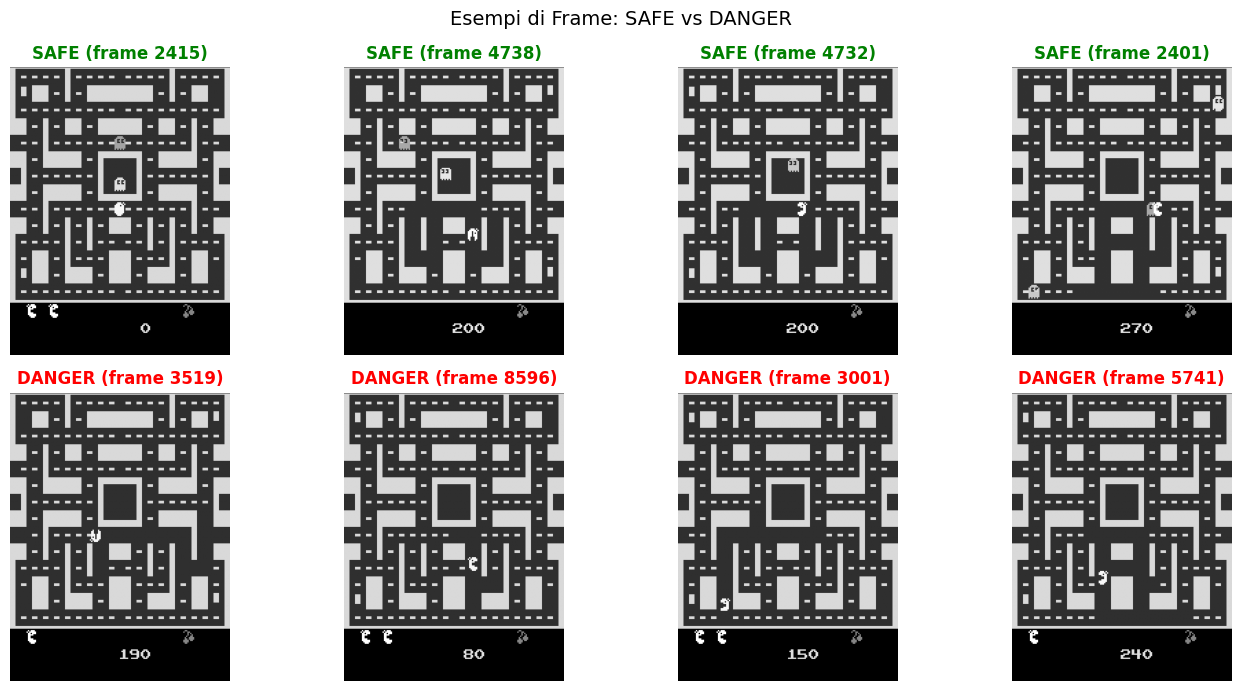

In [8]:
import matplotlib.pyplot as plt
import numpy as np

safe_indices = np.where(raw_labels == 0)[0]
danger_indices = np.where(raw_labels == 1)[0]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
np.random.seed(42)

for i, idx in enumerate(np.random.choice(safe_indices, 4, replace=False)):
    axes[0, i].imshow(raw_frames[idx], cmap='gray')
    axes[0, i].set_title(f'SAFE (frame {idx})', color='green', fontweight='bold')
    axes[0, i].axis('off')

for i, idx in enumerate(np.random.choice(danger_indices, 4, replace=False)):
    axes[1, i].imshow(raw_frames[idx], cmap='gray')
    axes[1, i].set_title(f'DANGER (frame {idx})', color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Esempi di Frame: SAFE vs DANGER', fontsize=14)
plt.tight_layout()
plt.show()

## 9 — Training Baseline (`PacmanWorldModel`)

**Filosofia**: lanciamo lo script `train_baseline.py` via subprocess. Vantaggio: l'addestramento è esattamente quello del repo, niente duplicazione.

Se vuoi velocizzare la demo, modifica `model.training.epochs=10` con un numero più basso.

In [9]:
# Training Baseline tramite script
import subprocess

# Per saltare il training e caricare pesi pre-addestrati, metti a True
SKIP_TRAINING_BASELINE = False

if SKIP_TRAINING_BASELINE and os.path.exists(BASELINE_PATH_INPUT):
    print(f"Skipping training, will load from {BASELINE_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_baseline.py'),
        f'training.checkpoint_dir={BASE_DIR}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Running: python /content/pacman-world-model/train_baseline.py training.checkpoint_dir=/content


Return code: 0


## 10 — Test 1: Reconstruction (Baseline)

Carica i pesi addestrati e visualizza la qualità della ricostruzione.

In [10]:
import torch

# Carica modello Baseline
baseline = PacmanWorldModel(latent_dim=64).to(device)
ckpt_path = BASELINE_PATH_OUTPUT if os.path.exists(BASELINE_PATH_OUTPUT) else BASELINE_PATH_INPUT

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    baseline.load_state_dict(ckpt['model_state_dict'])
    baseline.eval()
    print(f"Baseline loaded from {ckpt_path}")
else:
    print(f"⚠️ No Baseline checkpoint found. Run training first.")

Baseline loaded from /content/baseline_checkpoint.pth


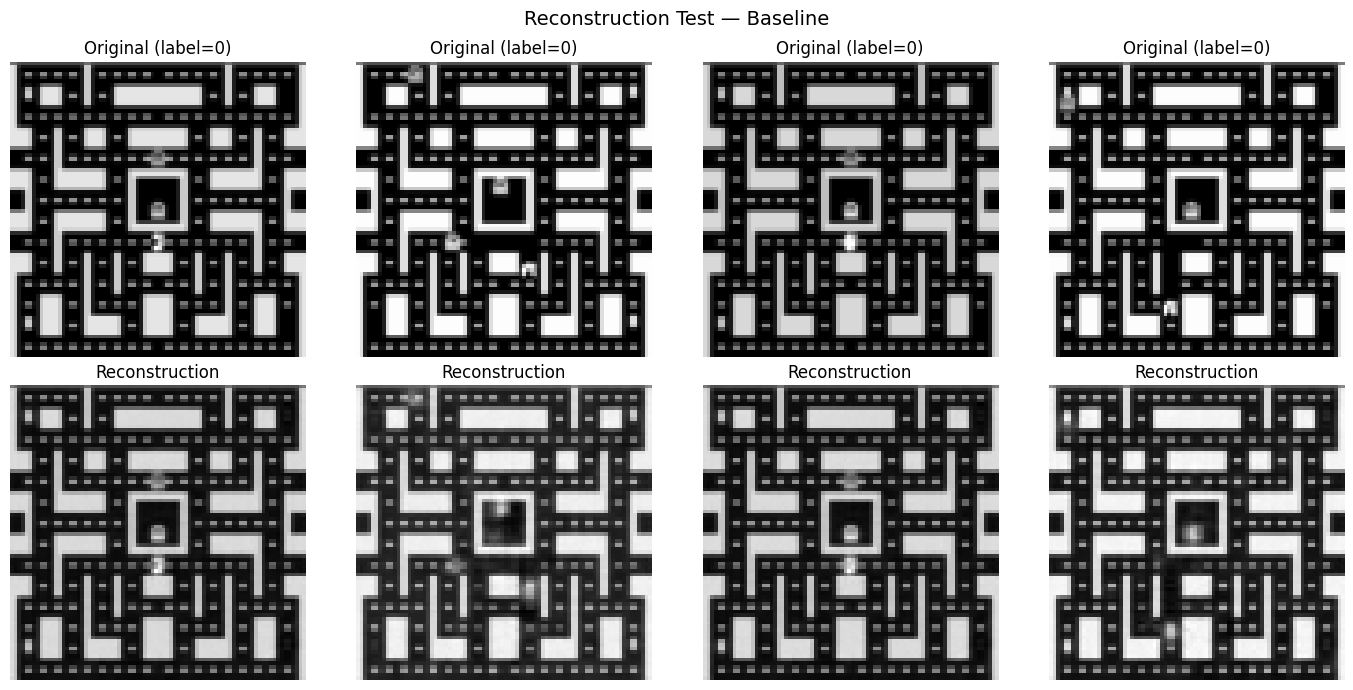

In [11]:
# Costruisci il loader per accedere ai frame test
_, test_loader_baseline, _ = build_loaders_single(
    raw_frames, raw_labels, batch_size=32, split_seed=42, sampler_seed=42
)

# Prendi un batch di test e visualizza ricostruzioni
sample_batch, sample_labels = next(iter(test_loader_baseline))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    reconstructions, predictions, latents = baseline(sample_batch)

# Plot 4 originali vs 4 ricostruzioni
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(sample_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Original (label={sample_labels[i].item()})')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Reconstruction')
    axes[1, i].axis('off')

plt.suptitle('Reconstruction Test — Baseline', fontsize=14)
plt.tight_layout()
plt.show()

## 11 — Test 2: Latent Interpolation (Baseline)

Interpola tra due frame nello spazio latente per dimostrare la smoothness della rappresentazione.

Frame A (SAFE):   idx 100
Frame B (DANGER): idx 175


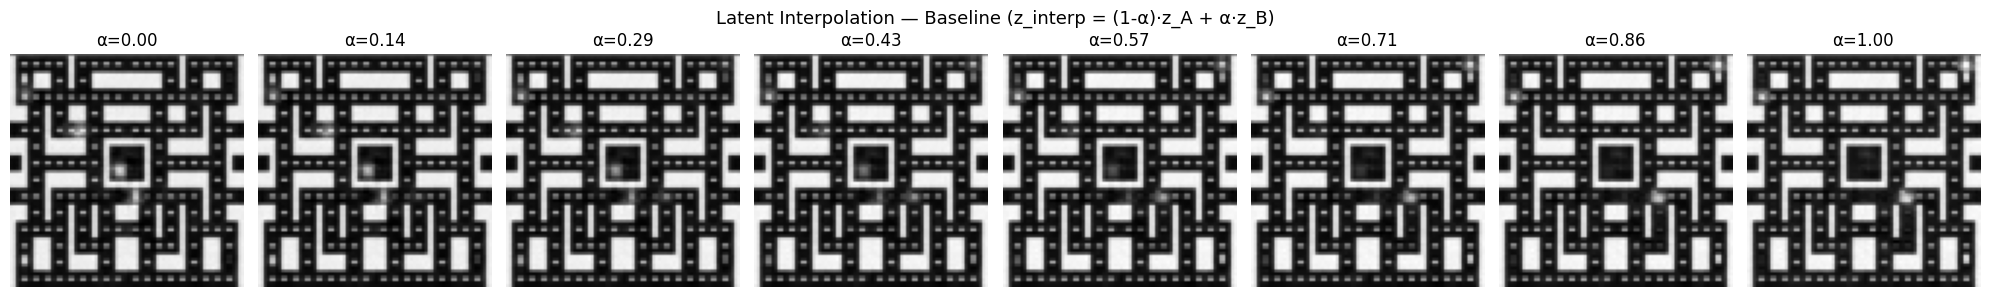

In [12]:
import numpy as np

# Trova due frame: uno SAFE e uno DANGER a 60 step di distanza
safe_idx = np.where(raw_labels == 0)[0][100]
danger_idx = safe_idx + 60
while danger_idx < len(raw_labels) and raw_labels[danger_idx] != 1:
    danger_idx += 1

print(f"Frame A (SAFE):   idx {safe_idx}")
print(f"Frame B (DANGER): idx {danger_idx}")

transform = get_transform_pipeline()
img_A = transform(raw_frames[safe_idx][0:170, :]).unsqueeze(0).to(device)
img_B = transform(raw_frames[danger_idx][0:170, :]).unsqueeze(0).to(device)

# Calcola latenti e fai TUTTA l'interpolazione dentro no_grad
num_steps = 8
alphas = np.linspace(0, 1, num_steps)
interpolated = []

with torch.no_grad():
    _, _, z_A = baseline(img_A)
    _, _, z_B = baseline(img_B)

    for alpha in alphas:
        z_interp = (1 - alpha) * z_A + alpha * z_B
        dec_reshaped = baseline.decoder_reshape(z_interp).view(-1, 64, 10, 10)
        img_recon = baseline.decoder_convs(dec_reshaped)
        interpolated.append(img_recon.detach().cpu())

# Plot
fig, axes = plt.subplots(1, num_steps, figsize=(20, 3))
for i, (img, alpha) in enumerate(zip(interpolated, alphas)):
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'α={alpha:.2f}')
    axes[i].axis('off')
plt.suptitle('Latent Interpolation — Baseline (z_interp = (1-α)·z_A + α·z_B)', fontsize=13)
plt.tight_layout()
plt.show()

## 12 — Test 3: Classification Report (Baseline)

--- Baseline Classification Report ---
              precision    recall  f1-score   support

        SAFE       1.00      0.92      0.96      1871
      DANGER       0.46      0.95      0.62       129

    accuracy                           0.92      2000
   macro avg       0.73      0.94      0.79      2000
weighted avg       0.96      0.92      0.94      2000



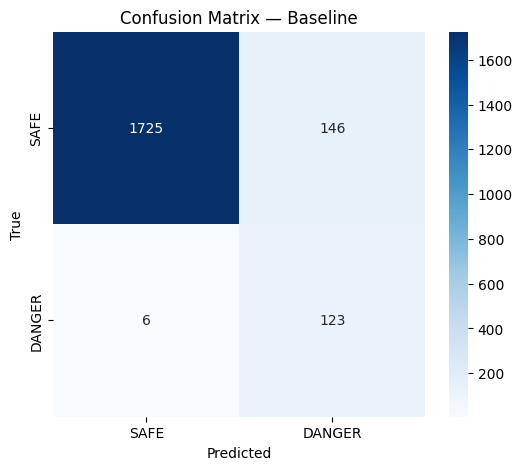

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
baseline.eval()
with torch.no_grad():
    for batch_imgs, batch_lbls in test_loader_baseline:
        batch_imgs = batch_imgs.to(device)
        _, pred, _ = baseline(batch_imgs)
        all_preds.extend((pred.squeeze() >= 0.5).long().cpu().numpy())
        all_labels.extend(batch_lbls.numpy())

print("--- Baseline Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['SAFE', 'DANGER']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['SAFE', 'DANGER'], yticklabels=['SAFE', 'DANGER'])
plt.title('Confusion Matrix — Baseline')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## 13 — Training VQ-VAE Multitask

In [14]:
SKIP_TRAINING_VQVAE = True

if SKIP_TRAINING_VQVAE and os.path.exists(VQVAE_PATH_INPUT):
    print(f"Skipping training, will load from {VQVAE_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_vqvae.py'),
        f'training.checkpoint_dir={BASE_DIR}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping training, will load from /content/drive/MyDrive/pacman-pesi/vqvae_checkpoint.pth


## 14 — Carica VQ-VAE e test

In [15]:
# Carica VQ-VAE
vqvae = VQVAE(num_embeddings=128, embedding_dim=64, commitment_cost=1.0).to(device)
ckpt_path = VQVAE_PATH_OUTPUT if os.path.exists(VQVAE_PATH_OUTPUT) else VQVAE_PATH_INPUT

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    vqvae.load_state_dict(ckpt['model_state_dict'])
    vqvae.eval()
    print(f"VQ-VAE loaded from {ckpt_path}")
else:
    print("⚠️ No VQ-VAE checkpoint found.")

# Verifica token attivi
all_indices = []
with torch.no_grad():
    for batch_images, _ in test_loader_baseline:
        z = vqvae.encoder(batch_images.to(device))
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, 64)
        dists = (
            torch.sum(z_flat**2, dim=1, keepdim=True)
            + torch.sum(vqvae.vq.embeddings**2, dim=1)
            - 2 * torch.matmul(z_flat, vqvae.vq.embeddings.t())
        )
        indices = torch.argmin(dists, dim=1)
        all_indices.append(indices.cpu())
active = len(torch.unique(torch.cat(all_indices)))
print(f"Active tokens: {active}/128")

VQ-VAE loaded from /content/drive/MyDrive/pacman-pesi/vqvae_checkpoint.pth
Active tokens: 128/128


In [16]:
# Test classificazione VQ-VAE
all_preds, all_labels = [], []
vqvae.eval()
with torch.no_grad():
    for batch_imgs, batch_lbls in test_loader_baseline:
        batch_imgs = batch_imgs.to(device)
        _, _, logits = vqvae(batch_imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_lbls.numpy())

print("--- VQ-VAE Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['SAFE', 'DANGER']))

--- VQ-VAE Classification Report ---
              precision    recall  f1-score   support

        SAFE       1.00      0.96      0.98      1871
      DANGER       0.64      0.95      0.76       129

    accuracy                           0.96      2000
   macro avg       0.82      0.95      0.87      2000
weighted avg       0.97      0.96      0.96      2000



## 15 — VQ-VAE Latent Interpolation

Differenza chiave col Baseline: dopo l'interpolazione lineare, **riquantizziamo** al codebook prima della decodifica.

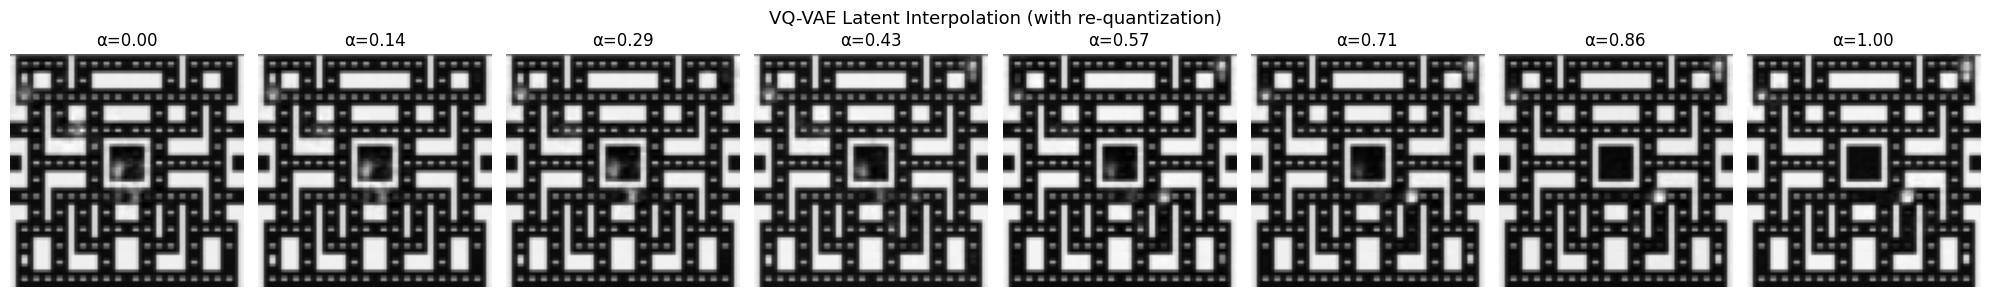

In [17]:
img_A = transform(raw_frames[safe_idx][0:170, :]).unsqueeze(0).to(device)
img_B = transform(raw_frames[danger_idx][0:170, :]).unsqueeze(0).to(device)

interpolated_vq = []

# Tutto il calcolo dentro no_grad
with torch.no_grad():
    z_A = vqvae.encoder(img_A)
    z_B = vqvae.encoder(img_B)

    for alpha in alphas:
        z_interp = (1 - alpha) * z_A + alpha * z_B
        q_interp, _ = vqvae.vq(z_interp)
        img_recon = vqvae.decoder(q_interp)
        interpolated_vq.append(img_recon.detach().cpu())

# Plot
fig, axes = plt.subplots(1, num_steps, figsize=(20, 3))
for i, (img, alpha) in enumerate(zip(interpolated_vq, alphas)):
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'α={alpha:.2f}')
    axes[i].axis('off')
plt.suptitle('VQ-VAE Latent Interpolation (with re-quantization)', fontsize=13)
plt.tight_layout()
plt.show()

## 16 — Training Temporal Transformer Classifier

Usa il VQ-VAE come feature extractor frozen. Lancia lo script `train_transformer.py`.

In [18]:
SKIP_TRAINING_TRANSFORMER = True

if SKIP_TRAINING_TRANSFORMER and os.path.exists(CLASSIFIER_PATH_INPUT):
    print(f"Skipping, will load from {CLASSIFIER_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_transformer.py'),
        f'training.checkpoint_dir={BASE_DIR}',
        f'model.training.vqvae_checkpoint={VQVAE_PATH_OUTPUT}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping, will load from /content/drive/MyDrive/pacman-pesi/transformer_classifier_checkpoint.pth


## 17 — Test Temporal Transformer

In [19]:
# Carica Temporal Transformer
transformer_classifier = TemporalTransformerClassifier(
    vqvae_encoder=vqvae.encoder, vq_module=vqvae.vq,
    seq_len=8, d_model=128, nhead=4, num_layers=4, dropout=0.1
).to(device)

ckpt_path = CLASSIFIER_PATH_OUTPUT if os.path.exists(CLASSIFIER_PATH_OUTPUT) else CLASSIFIER_PATH_INPUT
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    transformer_classifier.load_state_dict(ckpt['model_state_dict'])
    transformer_classifier.eval()
    print(f"Loaded from {ckpt_path}")

# Costruisci test loader sequenziale
_, _, test_seq_loader, _ = build_loaders_sequence(
    raw_frames, raw_labels, seq_len=8, batch_size=16,
    split_seed=42, sampler_seed=42
)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch_seqs, batch_lbls in test_seq_loader:
        batch_seqs = batch_seqs.to(device)
        logits = transformer_classifier(batch_seqs)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_lbls.numpy())

print("--- Temporal Transformer Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['SAFE', 'DANGER']))

Loaded from /content/drive/MyDrive/pacman-pesi/transformer_classifier_checkpoint.pth
--- Temporal Transformer Classification Report ---
              precision    recall  f1-score   support

        SAFE       1.00      0.98      0.99      1886
      DANGER       0.75      0.93      0.83       113

    accuracy                           0.98      1999
   macro avg       0.87      0.96      0.91      1999
weighted avg       0.98      0.98      0.98      1999



## 18 — Confronto Finale: i 3 Classificatori

Baseline (continuo, 1 frame):     92.40%
VQ-VAE (discreto, 1 frame):       96.00%
Temporal Transformer (8 frame):   97.85%


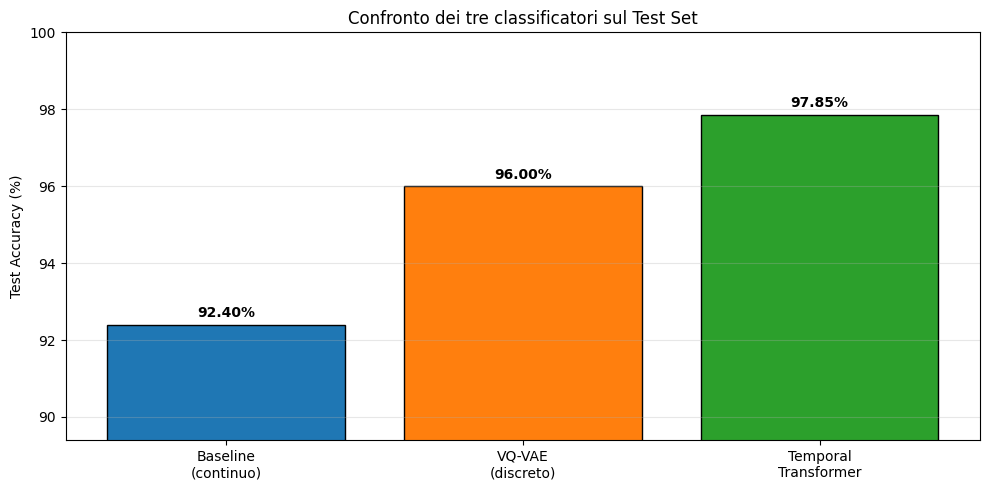

In [20]:
# Salva accuracy di tutti i 3 modelli e plottale insieme

# Re-evaluate baseline e vqvae per confronto
def get_accuracy(model, loader, is_baseline=False):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            if is_baseline:
                _, pred, _ = model(imgs)
                preds = (pred.squeeze() >= 0.5).long()
            else:
                _, _, logits = model(imgs)
                preds = logits.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return 100. * correct / total

acc_baseline = get_accuracy(baseline, test_loader_baseline, is_baseline=True)
acc_vqvae = get_accuracy(vqvae, test_loader_baseline, is_baseline=False)

# Per il transformer
correct, total = 0, 0
transformer_classifier.eval()
with torch.no_grad():
    for seqs, lbls in test_seq_loader:
        seqs = seqs.to(device)
        lbls = lbls.to(device)
        logits = transformer_classifier(seqs)
        correct += (logits.argmax(dim=1) == lbls).sum().item()
        total += lbls.size(0)
acc_transformer = 100. * correct / total

print(f"Baseline (continuo, 1 frame):     {acc_baseline:.2f}%")
print(f"VQ-VAE (discreto, 1 frame):       {acc_vqvae:.2f}%")
print(f"Temporal Transformer (8 frame):   {acc_transformer:.2f}%")

# Plot confronto
fig, ax = plt.subplots(figsize=(10, 5))
models_names = ['Baseline\n(continuo)', 'VQ-VAE\n(discreto)', 'Temporal\nTransformer']
accs = [acc_baseline, acc_vqvae, acc_transformer]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(models_names, accs, color=colors, edgecolor='black')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Confronto dei tre classificatori sul Test Set')
ax.set_ylim([min(accs) - 3, 100])
ax.grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 19 — Pruning del VQ-VAE Encoder (20% L1 Unstructured Global)

In [21]:
import torch.nn.utils.prune as prune

# Salva accuracy pre-pruning
acc_pre = acc_transformer
print(f"Accuracy PRE-pruning: {acc_pre:.2f}%")

# Identifica i layer Conv2d dell'encoder
modules_to_prune = []
for name, module in vqvae.encoder.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        modules_to_prune.append((module, 'weight'))

# Applica pruning globale 20%
prune.global_unstructured(
    modules_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

# Rendi permanente
for module, name in modules_to_prune:
    prune.remove(module, name)

# Misura sparsità
total_params, total_zeros = 0, 0
for i, (module, _) in enumerate(modules_to_prune):
    n_params = module.weight.nelement()
    n_zeros = float(torch.sum(module.weight == 0))
    sparsity = 100.0 * n_zeros / n_params
    total_params += n_params
    total_zeros += n_zeros
    print(f"Conv2d[{i}]: {sparsity:.2f}% sparso ({int(n_zeros)}/{n_params})")
print(f"\nSparsità globale: {100.0 * total_zeros / total_params:.2f}%")

# Re-eval con encoder pruned
correct, total = 0, 0
transformer_classifier.eval()
with torch.no_grad():
    for seqs, lbls in test_seq_loader:
        seqs, lbls = seqs.to(device), lbls.to(device)
        logits = transformer_classifier(seqs)
        correct += (logits.argmax(dim=1) == lbls).sum().item()
        total += lbls.size(0)
acc_post = 100. * correct / total

print(f"\nAccuracy POST-pruning: {acc_post:.2f}%")
print(f"Δ accuracy: {acc_post - acc_pre:+.2f}%")
if acc_post >= acc_pre - 1.0:
    print("✅ Pruning del 20% senza degrado significativo!")

Accuracy PRE-pruning: 97.85%
Conv2d[0]: 2.93% sparso (15/512)
Conv2d[1]: 9.47% sparso (3102/32768)
Conv2d[2]: 23.00% sparso (30141/131072)
Conv2d[3]: 15.27% sparso (1251/8192)

Sparsità globale: 20.00%

Accuracy POST-pruning: 97.85%
Δ accuracy: +0.00%
✅ Pruning del 20% senza degrado significativo!


## 20 — Training Token-level Prior

⚠️ Lungo (~30+ min su GPU). Salta o riduci epoche se serve solo demo.

In [22]:
SKIP_TRAINING_TOKEN_PRIOR = True

if SKIP_TRAINING_TOKEN_PRIOR and os.path.exists(PRIOR_PATH_INPUT):
    print(f"Skipping, will load from {PRIOR_PATH_INPUT}")
else:
    # NOTA: dopo il pruning bisogna ricaricare il VQ-VAE originale per il Prior
    # perché il Prior usa i token del VQ-VAE non-pruned per la consistenza dei codici
    vqvae_for_prior = VQVAE(num_embeddings=128, embedding_dim=64, commitment_cost=1.0).to(device)
    ckpt = torch.load(VQVAE_PATH_OUTPUT, map_location=device, weights_only=False)
    vqvae_for_prior.load_state_dict(ckpt['model_state_dict'])
    vqvae_for_prior.eval()

    cmd = [
        'python', os.path.join(REPO_DIR, 'train_token_prior.py'),
        f'training.checkpoint_dir={BASE_DIR}',
        f'model.training.vqvae_checkpoint={VQVAE_PATH_OUTPUT}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping, will load from /content/drive/MyDrive/pacman-pesi/transformer_prior_checkpoint.pth


## 21 — Diagnostica Codebook + Rollout Token-level

In [23]:
# Carica Token Prior
transformer_prior = TransformerPrior(num_embeddings=128).to(device)
ckpt_path = PRIOR_PATH_OUTPUT if os.path.exists(PRIOR_PATH_OUTPUT) else PRIOR_PATH_INPUT
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    transformer_prior.load_state_dict(ckpt['model_state_dict'])
    transformer_prior.eval()
    print(f"Token Prior loaded from {ckpt_path}")
else:
    print(f"⚠️ Token Prior checkpoint not found!")

# Ricarica anche il VQ-VAE originale (non pruned) per generazione coerente
vqvae_original = VQVAE(num_embeddings=128, embedding_dim=64, commitment_cost=1.0).to(device)

# FIX: fallback su INPUT path se OUTPUT non esiste
vqvae_ckpt_path = VQVAE_PATH_OUTPUT if os.path.exists(VQVAE_PATH_OUTPUT) else VQVAE_PATH_INPUT

if os.path.exists(vqvae_ckpt_path):
    ckpt = torch.load(vqvae_ckpt_path, map_location=device, weights_only=False)
    vqvae_original.load_state_dict(ckpt['model_state_dict'])
    vqvae_original.eval()
    print(f"Original VQ-VAE reloaded from {vqvae_ckpt_path}")
else:
    print(f"⚠️ VQ-VAE checkpoint not found!")

Token Prior loaded from /content/drive/MyDrive/pacman-pesi/transformer_prior_checkpoint.pth
Original VQ-VAE reloaded from /content/drive/MyDrive/pacman-pesi/vqvae_checkpoint.pth


Generating 5 frames token-by-token...


100%|██████████| 5/5 [00:02<00:00,  1.92it/s]


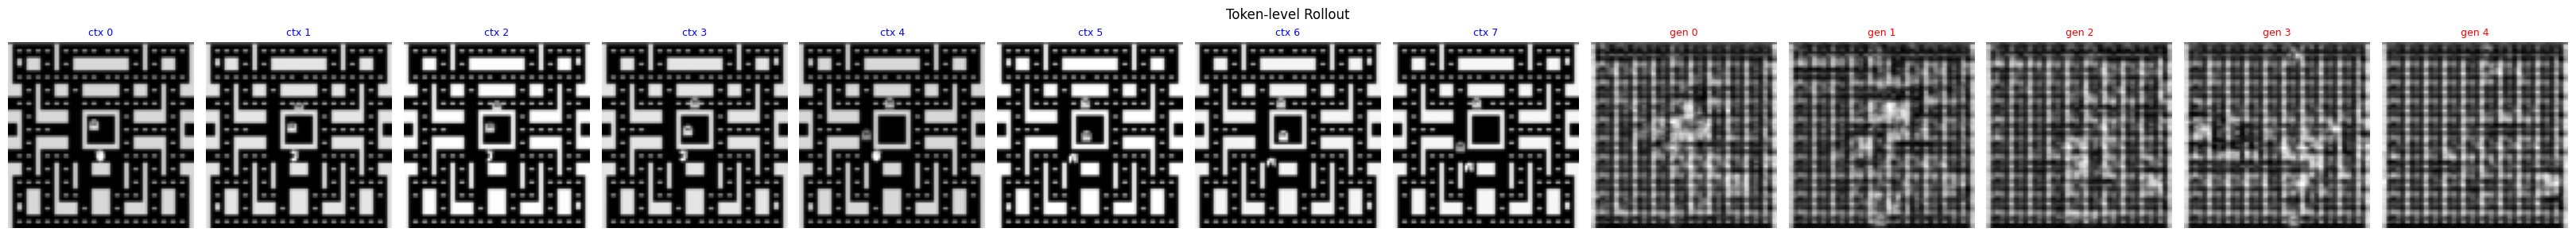

In [24]:
# Rollout token-level (5 frame)
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

TOKENS_PER_FRAME = 100
SEQ_LEN_TRAIN = 8
TOTAL_CTX_TOKENS = SEQ_LEN_TRAIN * TOKENS_PER_FRAME

def sample_with_temperature(logits, temperature=1.0, top_k=64):
    logits = logits / temperature
    top_k = min(top_k, logits.shape[-1])
    v, ix = torch.topk(logits, top_k)
    probs = F.softmax(v, dim=-1)
    next_token = torch.multinomial(probs, num_samples=1)
    return torch.gather(ix, -1, next_token)

num_frames_to_generate = 5

# Prendi una sequenza dal test set
sample_seqs, _ = next(iter(test_seq_loader))
sample_seqs = sample_seqs.to(device)
context_frames = sample_seqs[0:1, :SEQ_LEN_TRAIN]
B, S, C, H, W = context_frames.shape

with torch.no_grad():
    ctx_flat = context_frames.view(B*S, C, H, W)
    z_ctx = vqvae_original.encoder(ctx_flat)
    z_flat_ctx = z_ctx.permute(0,2,3,1).contiguous().view(-1, 64)
    dists = (
        torch.sum(z_flat_ctx**2, dim=1, keepdim=True)
        + torch.sum(vqvae_original.vq.embeddings**2, dim=1)
        - 2 * torch.matmul(z_flat_ctx, vqvae_original.vq.embeddings.t())
    )
    all_ctx_indices = torch.argmin(dists, dim=1)
    current_indices = all_ctx_indices.view(1, TOTAL_CTX_TOKENS)

    generated_frames = [context_frames[0, f].cpu().squeeze() for f in range(S)]

    print(f"Generating {num_frames_to_generate} frames token-by-token...")
    for f in tqdm(range(num_frames_to_generate)):
        for t in range(TOKENS_PER_FRAME):
            transformer_in = current_indices[:, -TOTAL_CTX_TOKENS:]
            logits = transformer_prior(transformer_in)
            next_tok = sample_with_temperature(logits[0, -1, :], temperature=0.9, top_k=64)
            current_indices = torch.cat([current_indices, next_tok.view(1, 1)], dim=1)

        frame_tokens = current_indices[0, -TOKENS_PER_FRAME:]
        encodings = F.one_hot(frame_tokens, 128).float()
        q_vec = torch.matmul(encodings, vqvae_original.vq.embeddings)
        q_spatial = q_vec.view(1, 10, 10, 64).permute(0, 3, 1, 2).contiguous()
        gen_img = vqvae_original.decoder(q_spatial).detach().cpu().squeeze()
        generated_frames.append(gen_img)

# Plot
total = len(generated_frames)
fig, axes = plt.subplots(1, total, figsize=(2.5*total, 3))
for i, img in enumerate(generated_frames):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    if i < S:
        axes[i].set_title(f'ctx {i}', color='blue', fontsize=9)
    else:
        axes[i].set_title(f'gen {i-S}', color='red', fontsize=9)
plt.suptitle('Token-level Rollout', fontsize=12)
plt.tight_layout()
plt.show()

## 22 — Sezione Estesa: Frame-level Prior (50k frame)

Per la sezione estesa serve un dataset più grande (50k frame). Genera o carica da cache.

In [25]:
# Genera o carica dataset 50k
DATASET_50K_PATH = os.path.join(DATA_DIR, 'raw_frames_50k.npz')

if not os.path.exists(DATASET_50K_PATH) and os.path.exists(DATASET_50K_INPUT):
    print(f"Copying cached 50k dataset from {DATASET_50K_INPUT}...")
    import shutil
    shutil.copy(DATASET_50K_INPUT, DATASET_50K_PATH)

raw_frames_50k, raw_labels_50k = load_or_collect(
    DATASET_50K_PATH, num_frames=50000, danger_window=15, seed=42
)

n_safe = int((raw_labels_50k == 0).sum())
n_danger = int((raw_labels_50k == 1).sum())
print(f"\nDataset 50k: SAFE={n_safe}, DANGER={n_danger}")

Copying cached 50k dataset from /content/drive/MyDrive/pacman-pesi/raw_frames_50k.npz...
Loading cached dataset from /content/pacman-world-model/data/raw_frames_50k.npz...

Dataset 50k: SAFE=46792, DANGER=3208


In [26]:
# Training Frame Prior
SKIP_TRAINING_FRAME_PRIOR = True

if SKIP_TRAINING_FRAME_PRIOR and os.path.exists(FRAME_PRIOR_PATH_INPUT):
    print(f"Skipping, will load from {FRAME_PRIOR_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_frame_prior.py'),
        'dataset=pacman_50k',
        f'training.checkpoint_dir={BASE_DIR}',
        f'model.training.vqvae_checkpoint={VQVAE_PATH_OUTPUT}',
        f'dataset.cache_path={DATASET_50K_PATH}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping, will load from /content/drive/MyDrive/pacman-pesi/frame_prior_checkpoint.pth


## 23 — Rollout Frame-level (15 frame autoregressivi)

Frame Prior loaded from /content/drive/MyDrive/pacman-pesi/frame_prior_checkpoint.pth
Generating 15 frames frame-by-frame...


100%|██████████| 15/15 [00:00<00:00, 232.57it/s]


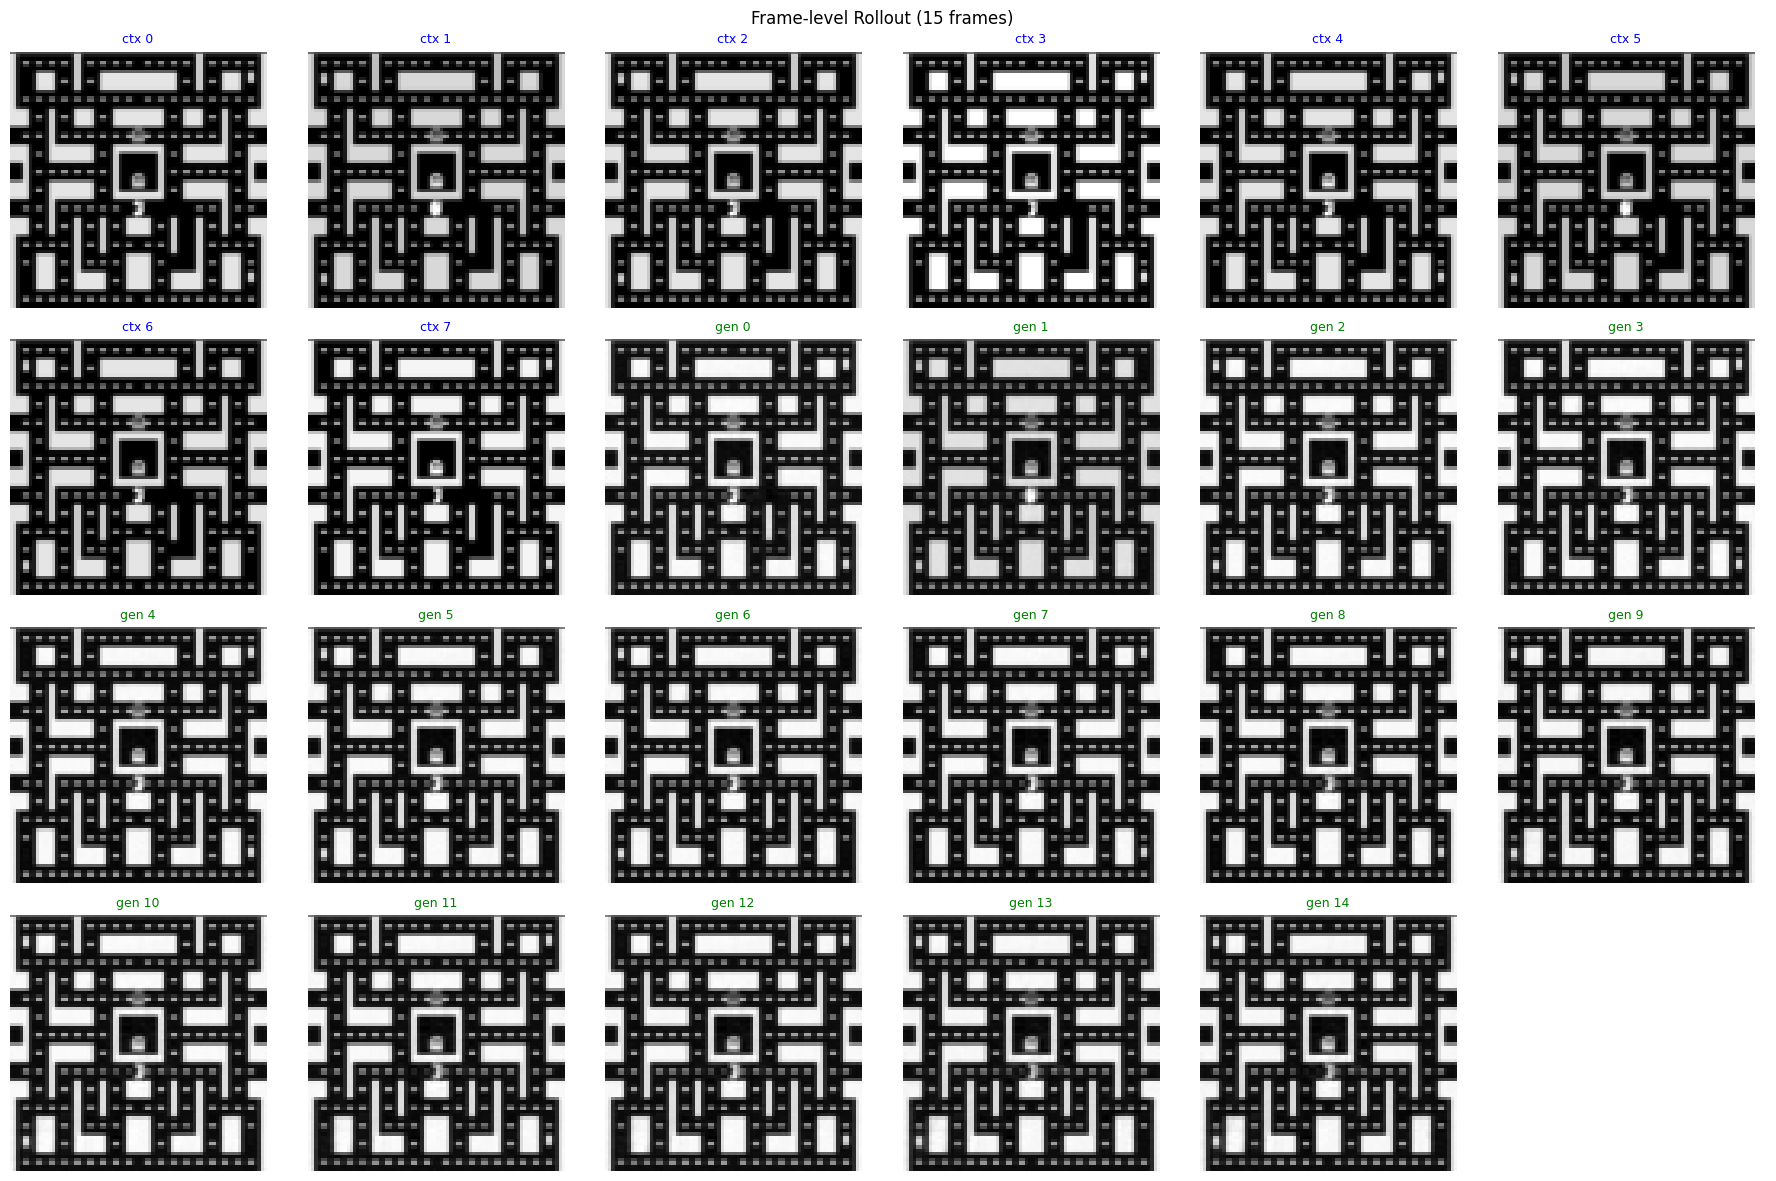

In [27]:
# Carica Frame Prior
frame_prior = FrameLevelPrior(
    latent_channels=64, latent_h=10, latent_w=10,
    d_model=256, nhead=8, num_layers=4, dropout=0.1
).to(device)

ckpt_path = FRAME_PRIOR_PATH_OUTPUT if os.path.exists(FRAME_PRIOR_PATH_OUTPUT) else FRAME_PRIOR_PATH_INPUT
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    frame_prior.load_state_dict(ckpt['model_state_dict'])
    frame_prior.eval()
    print(f"Frame Prior loaded from {ckpt_path}")

# Costruisci test loader frame prior
_, test_fp_loader = build_loaders_frame_prior(
    raw_frames_50k, seq_len=8, target_len=1, batch_size=16, split_seed=42
)

# Rollout
NUM_FRAMES_GENERATE = 15
sample_ctx, _ = next(iter(test_fp_loader))
context = sample_ctx[0:1].to(device)

with torch.no_grad():
    B, T, C, H, W = context.shape
    ctx_flat = context.view(B*T, C, H, W)
    z_history = vqvae_original.encoder(ctx_flat).view(B, T, 64, 10, 10)

    visual_frames = [context[0, f].cpu().squeeze() for f in range(T)]

    print(f"Generating {NUM_FRAMES_GENERATE} frames frame-by-frame...")
    for step in tqdm(range(NUM_FRAMES_GENERATE)):
        z_next = frame_prior(z_history)
        z_quantized, _ = vqvae_original.vq(z_next)
        gen_img = vqvae_original.decoder(z_quantized).detach().cpu().squeeze()
        visual_frames.append(gen_img)
        z_next_exp = z_next.unsqueeze(1)
        z_history = torch.cat([z_history, z_next_exp], dim=1)
        if z_history.shape[1] > T:
            z_history = z_history[:, -T:]

# Plot
total = len(visual_frames)
cols = 6
rows = (total + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.array(axes).flatten()
for i, img in enumerate(visual_frames):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    if i < T:
        axes[i].set_title(f'ctx {i}', color='blue', fontsize=9)
    else:
        axes[i].set_title(f'gen {i-T}', color='green', fontsize=9)
for j in range(total, len(axes)):
    axes[j].axis('off')
plt.suptitle('Frame-level Rollout (15 frames)', fontsize=12)
plt.tight_layout()
plt.show()

## 24 — Conclusioni

Riepilogo dei risultati ottenuti:

| Modello | Input | Test Accuracy | F1 DANGER |
|---|---|---|---|
| Baseline (continuo) | 1 frame | ~93.75% | 0.66 |
| VQ-VAE (discreto) | 1 frame | ~96.15% | 0.76 |
| Temporal Transformer | 8 frame | **~97.85%** | **0.83** |

**Pruning**: 20% del VQ-VAE encoder azzerato senza degrado di accuracy.

**Rollout generativo**:
- Token Prior: 1-2 frame coerenti, poi error accumulation
- Frame Prior: 15+ frame coerenti, struttura del labirinto preservata

Tutto il codice è disponibile nel repository GitHub. Per riprodurre i risultati lanciare gli script `train_*.py` in sequenza:

```bash
python train_baseline.py
python train_vqvae.py
python train_transformer.py
python train_token_prior.py
python train_frame_prior.py dataset=pacman_50k
```